# PYNQ CIFAR-100 — Softmax IP (K=100 padded to 128)

**K = 100** (actual classes) to **Padded to 128** (minimum 1 full scanner block)

### Padding
- K must be multiple of 8 LANES
- MIN_PAD = 128 (BLOCK_SIZE × LANES) to `K_IP = max(K, 128) = 128`
- 28 padding elements set to `0x8000` (-8.0 Q4.12) so no effect on softmax

### Architecture: 2-Pass Streaming
- **Pass 1**: Block-scan max + sum_exp
- **Pass 2**: Normalize (exp2 × recip) to AXI-S output
- **Bus**: 128-bit AXI-Stream, 8 elements/beat, 333 MHz, 0 DSP, 2 BRAM

In [1]:
# =========================================================================
# Configuration & Hardware Setup
# =========================================================================
import os, time, math, csv, datetime
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from pynq import Overlay, allocate, MMIO
from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt
import pandas as pd

BITSTREAM = "my_softmax15.bit"
IP_NAME   = "softmax_dl2_v6_0"
DMA_NAME  = "axi_dma_0"
NUM_CLASSES = 100
MIN_PAD     = 128            # BLOCK_SIZE(16) × LANES(8)
K_IP        = max(NUM_CLASSES, MIN_PAD) 
IP_FCLK_HZ  = 333_000_000
AXIS_WIDTH  = 128            # 128-bit AXI-Stream
IN_FRAC = 12; OUT_FRAC = 15
N_TEST  = 10000
WEIGHTS = "lightcnn_cifar100_best.pth"
LOG_CSV = "cifar100_v6_hw.csv"
CIFAR_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR_STD  = (0.2675, 0.2565, 0.2761)
class_names = [
    'apple','aquarium_fish','baby','bear','beaver','bed','bee','beetle',
    'bicycle','bottle','bowl','boy','bridge','bus','butterfly','camel',
    'can','castle','caterpillar','cattle','chair','chimpanzee','clock',
    'cloud','cockroach','couch','crab','crocodile','cup','dinosaur',
    'dolphin','elephant','flatfish','forest','fox','girl','hamster',
    'house','kangaroo','keyboard','lamp','lawn_mower','leopard','lion',
    'lizard','lobster','man','maple_tree','motorcycle','mountain','mouse',
    'mushroom','oak_tree','orange','orchid','otter','palm_tree','pear',
    'pickup_truck','pine_tree','plain','plate','poppy','porcupine',
    'possum','rabbit','raccoon','ray','road','rocket','rose','sea',
    'seal','shark','shrew','skunk','skyscraper','snail','snake','spider',
    'squirrel','streetcar','sunflower','sweet_pepper','table','tank',
    'telephone','television','tiger','tractor','train','trout','tulip',
    'turtle','wardrobe','whale','willow_tree','wolf','woman','worm'
]

print(f"Loading: {BITSTREAM}...")
overlay = Overlay(BITSTREAM)
dma = getattr(overlay, DMA_NAME)
dma_send = dma.sendchannel
dma_recv = dma.recvchannel
mmio = MMIO(overlay.ip_dict[IP_NAME]["phys_addr"], 0x10000)

# === v6.0 Register Map ===
REG_CTRL       = 0x00
REG_STATUS     = 0x04
REG_ARGMAX_IDX = 0x08
REG_ARGMAX_VAL = 0x0C
REG_TOTAL_LO   = 0x10; REG_TOTAL_HI  = 0x14
REG_P1_LO      = 0x18; REG_P1_HI     = 0x1C
REG_P2_LO      = 0x20; REG_P2_HI     = 0x24
REG_STALL_LO   = 0x28; REG_STALL_HI  = 0x2C
REG_K_CONFIG   = 0x30
REG_COMPUTE_LO = 0x34; REG_COMPUTE_HI = 0x38

CTRL_START_P1=0x01; CTRL_START_P2=0x02
CTRL_CLEAR_PERF=0x04; CTRL_CLEAR_ERR=0x08
STATUS_P1_DONE=0x01; STATUS_P2_DONE=0x02
STATUS_BUSY=0x04; STATUS_ERROR=0x08

def rd64(lo, hi): return (mmio.read(hi) << 32) | mmio.read(lo)

N_BEATS   = K_IP // 8          # 16 beats
K_PADDED  = N_BEATS * 8        # 128
BUF_WORDS = N_BEATS * 4        # 64 uint32 words

try: in_buf.freebuffer(); out_buf.freebuffer()
except: pass
in_buf  = allocate(shape=(BUF_WORDS,), dtype=np.uint32)
out_buf = allocate(shape=(BUF_WORDS,), dtype=np.uint32)

mmio.write(REG_K_CONFIG, K_IP)

print(f"Ready! {IP_FCLK_HZ/1e6:.0f} MHz | PAR8 {AXIS_WIDTH}b | K={NUM_CLASSES}to{K_IP} (padded) | {N_BEATS} beats")
print(f"Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM")

/usr/local/share/pynq-venv/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 
  warn(f"Failed to load image Python extension: {e}")


Loading: my_softmax15.bit...


Ready! 333 MHz | PAR8 128b | K=100to128 (padded) | 16 beats
Architecture: v6.0 Block-Scan Lookahead | 0 DSP, 2 BRAM


In [2]:
# =========================================================================
# Helpers and Softmax Runner
# =========================================================================
def pack_128b(int16_arr, k_actual, k_padded):
    n_beats = k_padded // 8
    padded = np.full(k_padded, -32768, dtype=np.int16)
    padded[:k_actual] = int16_arr[:k_actual]
    u = padded.view(np.uint16).astype(np.uint32)
    r = np.empty(n_beats * 4, dtype=np.uint32)
    for b in range(n_beats):
        s = b * 8
        r[b*4+0] = u[s]   | (u[s+1] << 16)
        r[b*4+1] = u[s+2] | (u[s+3] << 16)
        r[b*4+2] = u[s+4] | (u[s+5] << 16)
        r[b*4+3] = u[s+6] | (u[s+7] << 16)
    return r

def unpack_128b(w32, k_actual, k_padded):
    n_beats = k_padded // 8
    p = np.empty(k_padded, dtype=np.uint16)
    for b in range(n_beats):
        w = w32[b*4:b*4+4].astype(np.uint32); s = b * 8
        p[s]   = w[0] & 0xFFFF;       p[s+1] = (w[0] >> 16) & 0xFFFF
        p[s+2] = w[1] & 0xFFFF;       p[s+3] = (w[1] >> 16) & 0xFFFF
        p[s+4] = w[2] & 0xFFFF;       p[s+5] = (w[2] >> 16) & 0xFFFF
        p[s+6] = w[3] & 0xFFFF;       p[s+7] = (w[3] >> 16) & 0xFFFF
    return p[:k_actual].astype(np.float32) / (2**OUT_FRAC)

EPS = 1e-12
def kl_div(p, q):
    p, q = np.clip(p, EPS, 1), np.clip(q, EPS, 1)
    return float(np.sum(p * np.log(p / q)))

def cos_sim(a, b):
    d = np.linalg.norm(a) * np.linalg.norm(b)
    return float(np.dot(a, b) / d) if d > 0 else 0

def fmt_topk(idx, p):
    return ";".join([f"{int(i)}:{p[int(i)]:.6f}" for i in idx])

class SoftmaxRunnerV6:
    def __init__(self, nc, k_actual, k_padded):
        self.nc = nc
        self.k_actual = k_actual
        self.k_padded = k_padded
        self.errors = 0
        self.saturated = 0
    
    def run(self, logits):
        q = np.array(logits, dtype=np.float64) * (2**IN_FRAC)
        sat = np.clip(q, -32768, 32767)
        if int(np.sum(np.abs(q) > 32767)) > 0:
            self.saturated += 1
        int16 = np.round(sat).astype(np.int16)        
        packed = pack_128b(int16, self.k_actual, self.k_padded)
        np.copyto(in_buf, packed)
        mmio.write(REG_CTRL, CTRL_CLEAR_PERF)
        # Pass 1: Block-scan max + sum_exp
        mmio.write(REG_CTRL, CTRL_START_P1)
        dma_send.transfer(in_buf)
        dma_send.wait()
        for _ in range(2_000_000):
            if mmio.read(REG_STATUS) & STATUS_P1_DONE:
                break
        # Pass 2: Normalize to output (auto_p2_en=1)
        dma_recv.transfer(out_buf)
        mmio.write(REG_CTRL, CTRL_START_P2)
        dma_send.transfer(in_buf)
        dma_send.wait()
        dma_recv.wait()
        probs = unpack_128b(np.array(out_buf), self.k_actual, self.k_padded)
        aidx  = mmio.read(REG_ARGMAX_IDX)
        aval  = mmio.read(REG_ARGMAX_VAL) & 0xFFFF
        status = mmio.read(REG_STATUS)
        hw_err = bool(status & STATUS_ERROR)
        if hw_err:
            self.errors += 1
            mmio.write(REG_CTRL, CTRL_CLEAR_ERR)
        tc = rd64(REG_TOTAL_LO, REG_TOTAL_HI)
        p1c = rd64(REG_P1_LO, REG_P1_HI)
        p2c = rd64(REG_P2_LO, REG_P2_HI)
        sc = rd64(REG_STALL_LO, REG_STALL_HI)
        cc = rd64(REG_COMPUTE_LO, REG_COMPUTE_HI)
        valid = abs(float(np.sum(probs)) - 1.0) < 0.1
        pred = int(aidx) if aidx < self.nc else int(np.argmax(probs))
        return probs, pred, {
            'valid': valid, 'hw_error': hw_err,
            'argmax_idx': int(aidx), 'argmax_val': int(aval),
            'total': int(tc), 'p1': int(p1c), 'p2': int(p2c),
            'stall': int(sc), 'compute': int(cc),
            'ip_us': (tc / IP_FCLK_HZ) * 1e6 if tc > 0 else 0.0
        }
runner = SoftmaxRunnerV6(NUM_CLASSES, NUM_CLASSES, K_IP)
print(f"Runner ready (v6.0, 2-Pass Block-Scan, K={NUM_CLASSES}to{K_IP} padded)")

Runner ready (v6.0, 2-Pass Block-Scan, K=100to128 padded)


In [3]:
# =========================================================================
# Model and Data
# =========================================================================
class LightCNN_CIFAR100(nn.Module):
    def __init__(self, nc=100):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.1),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.Conv2d(256, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.15),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(512, 256), nn.ReLU(True), nn.Dropout(0.3),
            nn.Linear(256, nc))
    def forward(self, x): return self.classifier(self.features(x))

model = LightCNN_CIFAR100(); model.eval()
model.load_state_dict(torch.load(WEIGHTS, map_location="cpu"))
print(f"Model: LightCNN | Params: {sum(p.numel() for p in model.parameters()):,}")

tfm = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR_MEAN, CIFAR_STD)])
testset = datasets.CIFAR100('./data', train=False, download=True, transform=tfm)
testset_view = datasets.CIFAR100('./data', train=False, download=True, transform=None)
print(f"CIFAR-100: {len(testset)} images")

Model: LightCNN | Params: 2,485,412
Files already downloaded and verified
Files already downloaded and verified
CIFAR-100: 10000 images


In [4]:
# =========================================================================
# Sanity Test
# =========================================================================
print("Running sanity test (1 sample)...")
with torch.no_grad():
    img_t0, yt0 = testset[0]
    logits0 = model(img_t0.unsqueeze(0)).numpy().flatten().astype(np.float32)
    psw0 = F.softmax(torch.tensor(logits0), dim=0).numpy()

phw0, hp0, info0 = runner.run(logits0)
sp0 = int(np.argmax(psw0))

print(f"True={class_names[yt0]} | SW={class_names[sp0]} | HW={class_names[hp0] if hp0 < 100 else hp0}")
print(f"MAE={np.mean(np.abs(phw0-psw0)):.6f} | Cos={cos_sim(psw0,phw0):.6f}")
print(f"HW Sum={np.sum(phw0):.6f} | Valid={info0['valid']}")
print(f"Cycles: Total={info0['total']} P1={info0['p1']} P2={info0['p2']} Stall={info0['stall']}")
print("Sanity test passed!" if info0['valid'] and not info0['hw_error'] else "ISSUE DETECTED")

Running sanity test (1 sample)...
True=mountain | SW=road | HW=road
MAE=0.000017 | Cos=1.000000
HW Sum=0.999878 | Valid=True
Cycles: Total=182843 P1=101001 P2=81828 Stall=0
Sanity test passed!


In [5]:
# =========================================================================
# Full HW Evaluation
# =========================================================================
def run_hw_eval():
    total = min(N_TEST, len(testset))
    hdr = ["ID", "Label", "Name", "SW_Pred", "HW_Pred", "HW_eq_SW", "HW_eq_GT",
           "SW_Conf", "HW_Conf", "Top5_HW", "MAE", "KL", "Cos", "HW_Sum", "Valid",
           "Total_Cyc", "P1_Cyc", "P2_Cyc", "Stall_Cyc", "Compute_Cyc", "IP_us"]

    print(f"\n{'='*70}")
    print(f" HW EVAL: {total} CIFAR-100 | K={NUM_CLASSES}to{K_IP} (pad {MIN_PAD}) | v6.0 Block-Scan")
    print(f" Architecture: PAR8, {AXIS_WIDTH}-bit AXI-S, {IP_FCLK_HZ/1e6:.0f} MHz")
    print(f" Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages")
    print(f" Padding: {NUM_CLASSES}to{K_IP} ({K_IP - NUM_CLASSES} elements, {N_BEATS} beats)")
    print(f"{'='*70}\n")

    t0 = time.time()
    c_sw = c_hw = c_hw5 = mism = 0
    mae_s = kl_s = cos_s = ip_s = 0.0
    inv = 0
    tc_s = p1_s = p2_s = sc_s = cc_s = 0

    with open(LOG_CSV, "w", newline="") as f:
        w = csv.writer(f); w.writerow(hdr)
        with torch.no_grad():
            for i in range(total):
                img_t, yt = testset[i]
                logits = model(img_t.unsqueeze(0)).numpy().flatten().astype(np.float32)
                psw = F.softmax(torch.tensor(logits), dim=0).numpy()
                sp = int(np.argmax(psw))
                phw, hp, info = runner.run(logits)

                c_sw += int(sp == yt); c_hw += int(hp == yt)
                hw5 = np.argsort(-phw)[:5]
                if yt in hw5: c_hw5 += 1
                if hp != sp: mism += 1

                mae = float(np.mean(np.abs(phw - psw))); mae_s += mae
                kl = kl_div(psw, phw); kl_s += kl
                cs = cos_sim(psw, phw); cos_s += cs
                if not info['valid']: inv += 1

                tc_s += info['total']; p1_s += info['p1']
                p2_s += info['p2'];    sc_s += info['stall']
                cc_s += info['compute']
                ip_s += info['ip_us']

                w.writerow([i, yt, class_names[yt], sp, hp, int(hp==sp), int(hp==yt),
                    f"{psw[sp]:.6f}",
                    f"{phw[hp]:.6f}" if hp < NUM_CLASSES else "0",
                    fmt_topk(hw5, phw),
                    f"{mae:.6f}", f"{kl:.6f}", f"{cs:.6f}",
                    f"{np.sum(phw):.6f}", info['valid'],
                    info['total'], info['p1'], info['p2'],
                    info['stall'], info['compute'],
                    f"{info['ip_us']:.4f}"])

                if (i+1) % 1000 == 0 or (i+1) == total:
                    el = time.time() - t0
                    print(f"  [{i+1:>5d}/{total}] HW={c_hw/(i+1)*100:.2f}% "
                          f"Top5={c_hw5/(i+1)*100:.2f}% Mis={mism} | {el:.1f}s")

    elapsed = time.time() - t0; n = total
    at = tc_s / n
    ac = cc_s / n

    print(f"\n{'='*70}")
    print(f"  CIFAR-100 v6.0 REPORT (K={NUM_CLASSES}to{K_IP}, {N_BEATS} beats)")
    print(f"{'='*70}")
    print(f"Time: {elapsed:.1f}s | FPS: {n/elapsed:.0f}")
    print(f"\n--- ACCURACY ---")
    print(f"SW Top-1: {c_sw/n*100:.2f}% | HW Top-1: {c_hw/n*100:.2f}% | HW Top-5: {c_hw5/n*100:.2f}%")
    print(f"Loss: {(c_sw-c_hw)/n*100:.4f}% | Mismatches: {mism}")
    print(f"\n--- METRICS ---")
    print(f"MAE: {mae_s/n:.6f} | KL: {kl_s/n:.6f} | Cos: {cos_s/n:.6f}")
    print(f"Errors: {runner.errors} | Invalid: {inv} | Saturated: {runner.saturated}")
    print(f"\n--- PERFORMANCE (Avg per softmax) ---")
    print(f"TOTAL:   {at:.1f} cyc ({at/IP_FCLK_HZ*1e6:.4f} us)")
    print(f"PASS 1:  {p1_s/n:.1f} cyc")
    print(f"PASS 2:  {p2_s/n:.1f} cyc")
    print(f"STALL:   {sc_s/n:.1f} cyc (rescale)")
    print(f"COMPUTE: {ac:.1f} cyc (pure IP, excl DMA wait)")
    print(f"\n--- THROUGHPUT ---")
    print(f"Clock:         {IP_FCLK_HZ/1e6:.0f} MHz")
    if at > 0:
        elems_s = K_IP * IP_FCLK_HZ / at
        gbps_data = (elems_s * 16) / 1e9
        print(f"Elements:      {elems_s/1e6:.2f} Melem/s (total)")
        print(f"Data BW:       {gbps_data:.2f} Gbps (16-bit elements)")
    if ac > 0:
        comp_elems_s = K_IP * IP_FCLK_HZ / ac
        comp_gbps = (comp_elems_s * 16) / 1e9
        print(f"Compute BW:    {comp_gbps:.2f} Gbps (pure compute, no DMA)")
    print(f"\nCSV: {LOG_CSV}")
    print(f"{'='*70}")
    return n/elapsed, c_hw/n*100

fps, acc = run_hw_eval()


 HW EVAL: 10000 CIFAR-100 | K=100to128 (pad 128) | v6.0 Block-Scan
 Architecture: PAR8, 128-bit AXI-S, 333 MHz
 Pipeline: scan(3)+exp2(6)+csa(1)+booth(9)+shift(1)+clamp(1) = 21 stages
 Padding: 100to128 (28 elements, 16 beats)

  [ 1000/10000] HW=73.10% Top5=92.70% Mis=2 | 39.1s
  [ 2000/10000] HW=73.60% Top5=93.40% Mis=2 | 77.5s
  [ 3000/10000] HW=73.63% Top5=93.50% Mis=2 | 115.5s
  [ 4000/10000] HW=73.75% Top5=93.80% Mis=2 | 153.6s
  [ 5000/10000] HW=73.40% Top5=93.70% Mis=2 | 191.9s
  [ 6000/10000] HW=73.88% Top5=93.83% Mis=2 | 230.0s
  [ 7000/10000] HW=73.83% Top5=93.79% Mis=2 | 268.3s
  [ 8000/10000] HW=73.61% Top5=93.70% Mis=2 | 306.4s
  [ 9000/10000] HW=73.80% Top5=93.78% Mis=2 | 351.4s
  [10000/10000] HW=73.98% Top5=93.78% Mis=2 | 393.1s

  CIFAR-100 v6.0 REPORT (K=100to128, 16 beats)
Time: 393.1s | FPS: 25

--- ACCURACY ---
SW Top-1: 74.00% | HW Top-1: 73.98% | HW Top-5: 93.78%
Loss: 0.0200% | Mismatches: 2

--- METRICS ---
MAE: 0.000130 | KL: 0.003424 | Cos: 0.999797
Errors:


 CIFAR #0 (True: mountain)
 SW: road (68) | HW: road (68) | MISMATCH ✗
 Logits: [-1.6308, 6.1634]
 MAE: 0.000017 | KL: 0.000131
 HW Sum: 0.999878 | Valid: True
 Total: 163693 cyc | P1: 83590 | P2: 80089
 Stall: 0 | Compute: 71

 Top-5 HW:
   1. road                 77.0172%
   2. bridge               1.5015%
   3. train                1.2360%
   4. spider               1.2146%
   5. man                  1.1902%


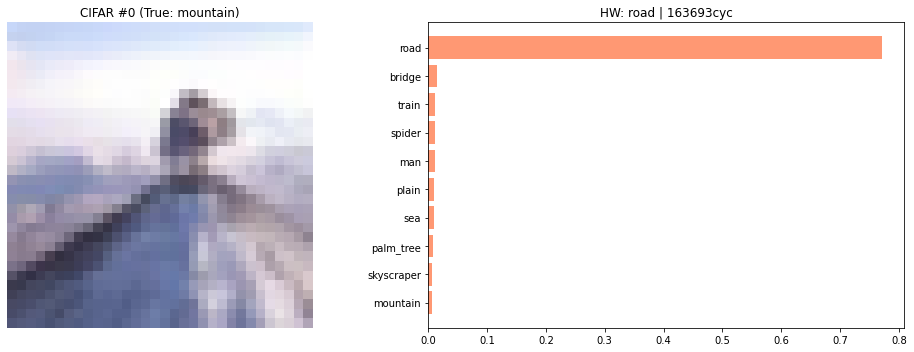

In [6]:
# =========================================================================
# Single Image Test
# =========================================================================
def load_custom_image(path):
    """Load a custom image file and preprocess for CIFAR-100 LightCNN."""
    pil = Image.open(path).convert('RGB').resize((32, 32), Image.BILINEAR)
    img_t = tfm(pil)
    return img_t, pil

def test_image(idx_or_path):
    """Test a single image on both SW and HW softmax.
    
    Args:
        idx_or_path: int  to CIFAR-100 test set index (0-9999)
                     str  to path to custom image (e.g. '../cat.jpg')
    """
    if isinstance(idx_or_path, str):
        img_t, pil = load_custom_image(idx_or_path)
        yt = -1
        label_str = f'Custom: {os.path.basename(idx_or_path)}'
    else:
        img_t, yt = testset[idx_or_path]
        pil, _ = testset_view[idx_or_path]
        label_str = f'CIFAR #{idx_or_path} (True: {class_names[yt]})'

    with torch.no_grad():
        logits = model(img_t.unsqueeze(0)).numpy().flatten().astype(np.float32)
        psw = F.softmax(torch.tensor(logits), dim=0).numpy()
    phw, hp, info = runner.run(logits); sp = int(np.argmax(psw))

    match_str = ''
    if yt >= 0:
        match_str = ' | MATCH' if hp == yt else ' | MISMATCH'

    hw_name = class_names[hp] if hp < NUM_CLASSES else f'idx_{hp}'
    sw_name = class_names[sp] if sp < NUM_CLASSES else f'idx_{sp}'

    print(f"\n{'='*60}")
    print(f" {label_str}")
    print(f" SW: {sw_name} ({sp}) | HW: {hw_name} ({hp}){match_str}")
    print(f"{'='*60}")
    print(f" Logits: [{np.min(logits):.4f}, {np.max(logits):.4f}]")
    print(f" MAE: {np.mean(np.abs(phw-psw)):.6f} | KL: {kl_div(psw,phw):.6f}")
    print(f" HW Sum: {np.sum(phw):.6f} | Valid: {info['valid']}")
    print(f" Total: {info['total']} cyc | P1: {info['p1']} | P2: {info['p2']}")
    print(f" Stall: {info['stall']} | Compute: {info['compute']}")

    # Top-5 HW predictions
    top5 = np.argsort(-phw)[:5]
    print(f"\n Top-5 HW:")
    for rank, idx in enumerate(top5):
        name = class_names[idx] if idx < NUM_CLASSES else f'idx_{idx}'
        marker = ' ←' if yt >= 0 and idx == yt else ''
        print(f"   {rank+1}. {name:20s} {phw[idx]:.4%}{marker}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].imshow(pil); axes[0].axis('off')
    axes[0].set_title(label_str)

    top10 = np.argsort(-phw)[:10]
    axes[1].barh(range(10), phw[top10], color='coral', alpha=0.8)
    axes[1].set_yticks(range(10))
    axes[1].set_yticklabels([class_names[i] if i < NUM_CLASSES else f'idx_{i}' for i in top10])
    axes[1].invert_yaxis()
    axes[1].set_title(f'HW: {hw_name} | {info["total"]}cyc')
    plt.tight_layout(); plt.show()

# Test with CIFAR-100 dataset
test_image(0)


 Custom: lawn.jpg
 SW: lawn_mower (41) | HW: lawn_mower (41)
 Logits: [-1.8454, 5.1342]
 MAE: 0.000013 | KL: 0.000770
 HW Sum: 0.999237 | Valid: True
 Total: 170982 cyc | P1: 90190 | P2: 80778
 Stall: 0 | Compute: 71

 Top-5 HW:
   1. lawn_mower           42.0288%
   2. beetle               16.8762%
   3. tractor              4.4647%
   4. cockroach            3.2867%
   5. spider               2.5543%


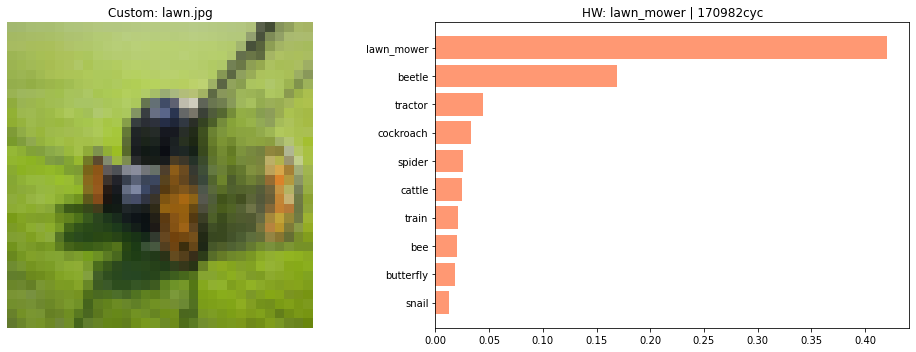

In [7]:
test_image("./lawn.jpg")


 Custom: motor.jpg
 SW: motorcycle (48) | HW: motorcycle (48)
 Logits: [-1.6889, 6.5163]
 MAE: 0.000022 | KL: -0.000138
 HW Sum: 1.000153 | Valid: True
 Total: 171212 cyc | P1: 88901 | P2: 82297
 Stall: 0 | Compute: 71

 Top-5 HW:
   1. motorcycle           84.6710%
   2. telephone            0.8118%
   3. lawn_mower           0.7141%
   4. tulip                0.6073%
   5. bicycle              0.5096%


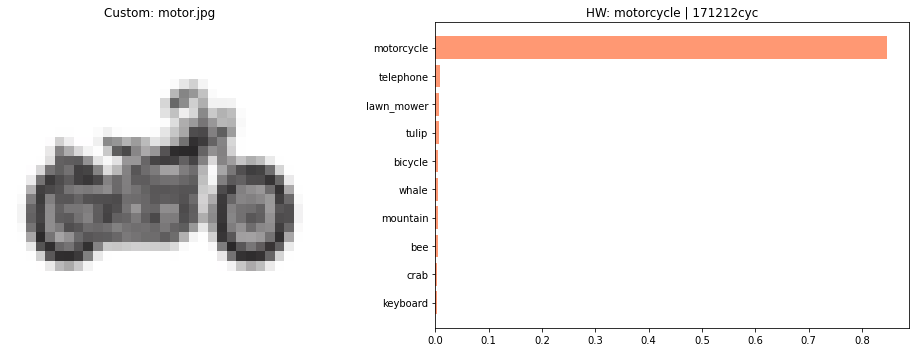

In [8]:
test_image("./motor.jpg")


 Custom: sunflower.jpg
 SW: sunflower (82) | HW: sunflower (82)
 Logits: [-1.9727, 7.6703]
 MAE: 0.000026 | KL: -0.000145
 HW Sum: 1.000183 | Valid: True
 Total: 170669 cyc | P1: 89840 | P2: 80815
 Stall: 0 | Compute: 71

 Top-5 HW:
   1. sunflower            94.5618%
   2. bee                  0.3082%
   3. cloud                0.2777%
   4. cockroach            0.1831%
   5. plain                0.1740%


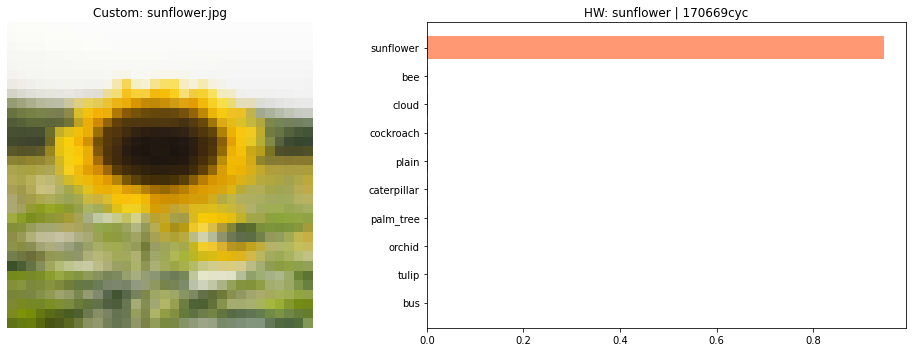

In [9]:
test_image("./sunflower.jpg")

In [10]:
# =========================================================================
# Cell 8: Cleanup
# =========================================================================
try: in_buf.freebuffer(); out_buf.freebuffer()
except: pass
print('Buffers freed. Done.')

Buffers freed. Done.
